In [1]:
import pandas as pd
import numpy as np

# Load the CSV
df = pd.read_csv('final_ct_head_dataset.csv')

# Quick check
print(df.shape)
print(df['ct_classification'].value_counts())
print(df.isnull().mean().sort_values(ascending=False))

(4638, 57)
ct_classification
Negative                   3383
Positive                   1004
Unclear                     169
Post-surgical/Unchanged      82
Name: count, dtype: int64
npi_right_min                1.000000
npi_left_min                 1.000000
temp_max                     0.944804
pco2_max                     0.750539
map_min                      0.603708
rass_last                    0.368262
sbp_max                      0.366106
ptt                          0.263044
inr                          0.263044
pupil_size_right             0.245364
pupil_size_left              0.245149
gcs_total_min                0.147262
gcs_motor_last_min           0.145106
gcs_verbal_last_min          0.142087
gcs_eye_last_min             0.140147
platelets                    0.117508
glucose                      0.111902
sodium                       0.108452
rr_min                       0.067055
spo2_min                     0.066624
hr_min                       0.061665
hr_max             

Classes: ['Negative' 'Positive']
Positive rate: 22.9%

Numeric features (40): ['age', 'gcs_eye_last_min', 'gcs_verbal_last_min', 'gcs_motor_last_min', 'gcs_total_min', 'rass_last', 'hr_min', 'hr_max', 'spo2_min', 'rr_min', 'flag_abnormal_pupils', 'flag_altered_loc', 'flag_seizure', 'cam_ms_change', 'cam_inattention', 'cam_altered_loc', 'cam_disorganized_thinking', 'flag_cam_positive', 'cardiac_arrest', 'respiratory_arrest', 'fall', 'flag_gcs_low', 'flag_sbp_high', 'flag_spo2_low', 'flag_rr_low', 'flag_npi_low', 'new_vasopressor', 'new_antiepileptic', 'inr', 'ptt', 'platelets', 'sodium', 'glucose', 'flag_coagulopathy', 'flag_ptt_elevated', 'flag_hyponatremia', 'inr_missing', 'ptt_missing', 'gcs_total_min_missing', 'rass_last_missing']
Categorical features (2): ['gender', 'race']

Train: 3519 rows | positive rate: 23.2%
Test:  868 rows  | positive rate: 21.7%

Training Logistic Regression...
  AUROC: 0.714 | AUPRC: 0.437 | Accuracy: 0.675
              precision    recall  f1-score   sup

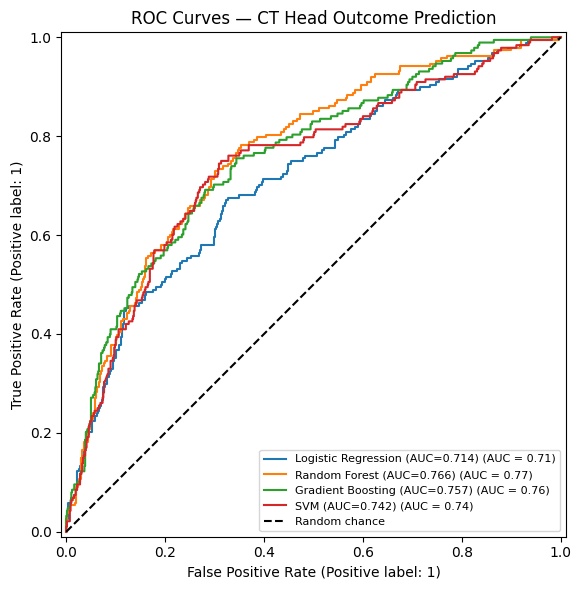

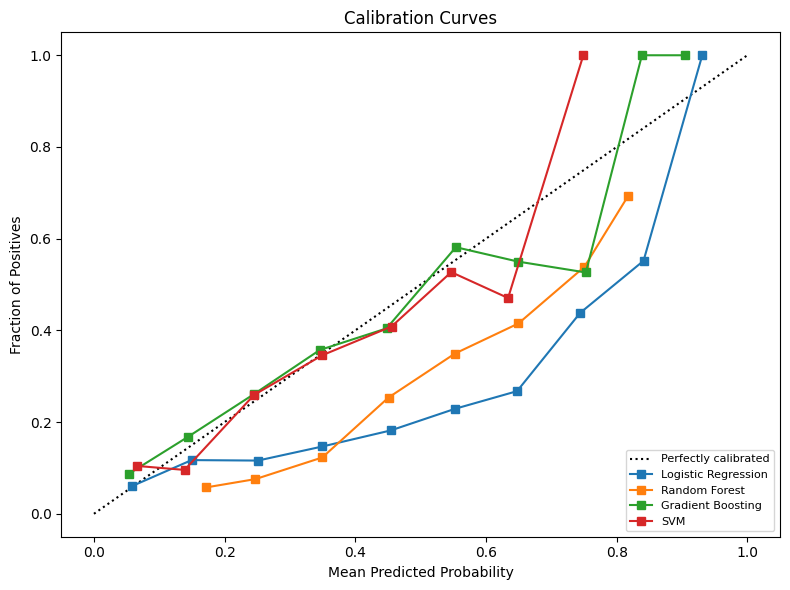

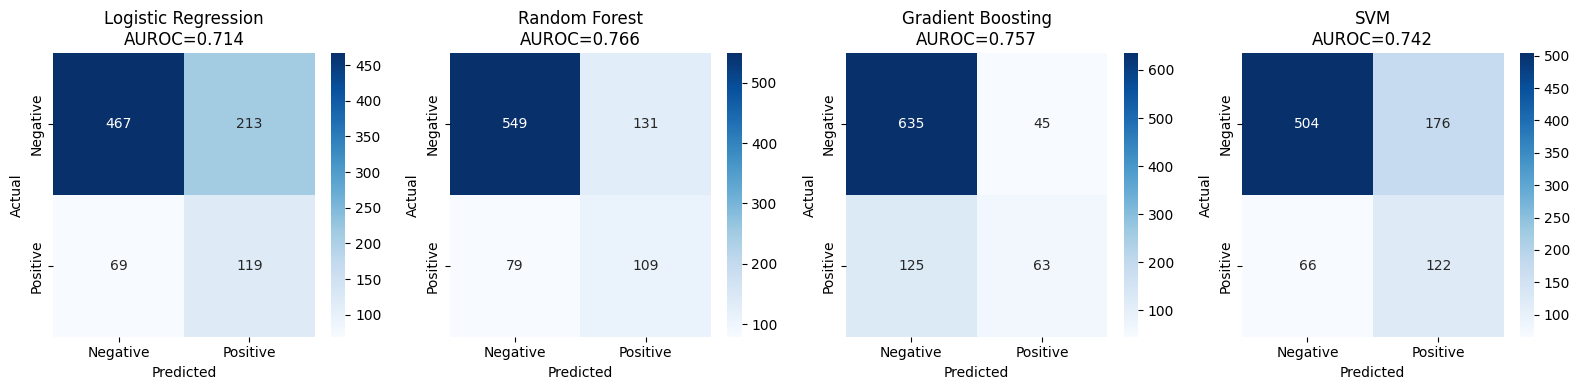

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (brier_score_loss, classification_report, accuracy_score, f1_score,
                             roc_auc_score, average_precision_score,
                             RocCurveDisplay, confusion_matrix)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

# ── 1. Load and filter ────────────────────────────────────────────────────────
df = pd.read_csv('final_ct_head_dataset.csv')
df = df[df['ct_classification'].isin(['Positive', 'Negative'])].copy()

# ── 2. Drop high-missingness and identifier columns ───────────────────────────
cols_to_drop = [
    'note_id', 'ct_order_time', 'icu_intime',
    'npi_right_min', 'npi_left_min',      # 100% missing
    'temp_max', 'flag_fever',              # 94% missing
    'pco2_max', 'flag_hypercapnia',        # 75% missing
    'map_min', 'flag_map_low',             # 60% missing
    'sbp_max',                             # 37% missing
    'pupil_size_right', 'pupil_size_left','first_careunit', 'icu_hour_at_ct', 'shift',  # text, flag kept
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# ── 3. Add missingness flags before imputation ────────────────────────────────
for col in ['inr', 'ptt', 'gcs_total_min', 'rass_last']:
    if col in df.columns:
        df[f'{col}_missing'] = df[col].isna().astype(int)

# ── 4. Encode target ──────────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df['ct_classification'])  # Negative=0, Positive=1
print(f"Classes: {le.classes_}")
print(f"Positive rate: {y.mean():.1%}")

# ── 5. Features ───────────────────────────────────────────────────────────────
exclude = ['ct_classification', 'subject_id', 'hadm_id', 'stay_id']
X = df.drop(columns=[c for c in exclude if c in df.columns])
groups = df['subject_id']

# ── 6. Identify numeric and categorical columns ───────────────────────────────
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# ── 7. Preprocessing pipelines ───────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ── 8. Patient-level train/test split ─────────────────────────────────────────
# Critical: split by patient not by row to avoid data leakage
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"\nTrain: {len(X_train)} rows | positive rate: {y_train.mean():.1%}")
print(f"Test:  {len(X_test)} rows  | positive rate: {y_test.mean():.1%}")

# ── 9. Define models ──────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=15,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    ),
    'SVM': SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    )
}

# ── 10. Train, evaluate, and collect results ──────────────────────────────────
results = {}
pos_class_idx = le.transform(['Positive'])[0]

for name, clf in models.items():
    print(f"\nTraining {name}...")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, pos_class_idx]

    auroc = roc_auc_score(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)
    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred, pos_label=pos_class_idx)  # add this
    brier = brier_score_loss(y_test, y_prob) 

    results[name] = {
        'pipeline': pipeline,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'AUROC': auroc,
        'AUPRC': auprc,
        'Accuracy': acc,
        'F1': f1,        # add this
        'Brier': brier
    }

    print(f"  AUROC: {auroc:.3f} | AUPRC: {auprc:.3f} | Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── 11. Summary table ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    name: {
        'AUROC':    f"{res['AUROC']:.3f}",
        'AUPRC':    f"{res['AUPRC']:.3f}",
        'Accuracy': f"{res['Accuracy']:.3f}"
    }
    for name, res in results.items()
}).T

print("\n── Model Comparison ──")
print(summary)
summary.to_csv('model_comparison.csv')

# ── 12. ROC curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'], ax=ax,
        name=f"{name} (AUC={res['AUROC']:.3f})"
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random chance')
ax.set_title('ROC Curves — CT Head Outcome Prediction')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300)
plt.show()

# ── 13. Calibration curves ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
for name, res in results.items():
    prob_true, prob_pred = calibration_curve(
        y_test == pos_class_idx, res['y_prob'], n_bins=10
    )
    ax.plot(prob_pred, prob_true, 's-', label=name)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=300)
plt.show()

# ── 14. Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(4*len(models), 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_, ax=ax)
    ax.set_title(f"{name}\nAUROC={res['AUROC']:.3f}")
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()

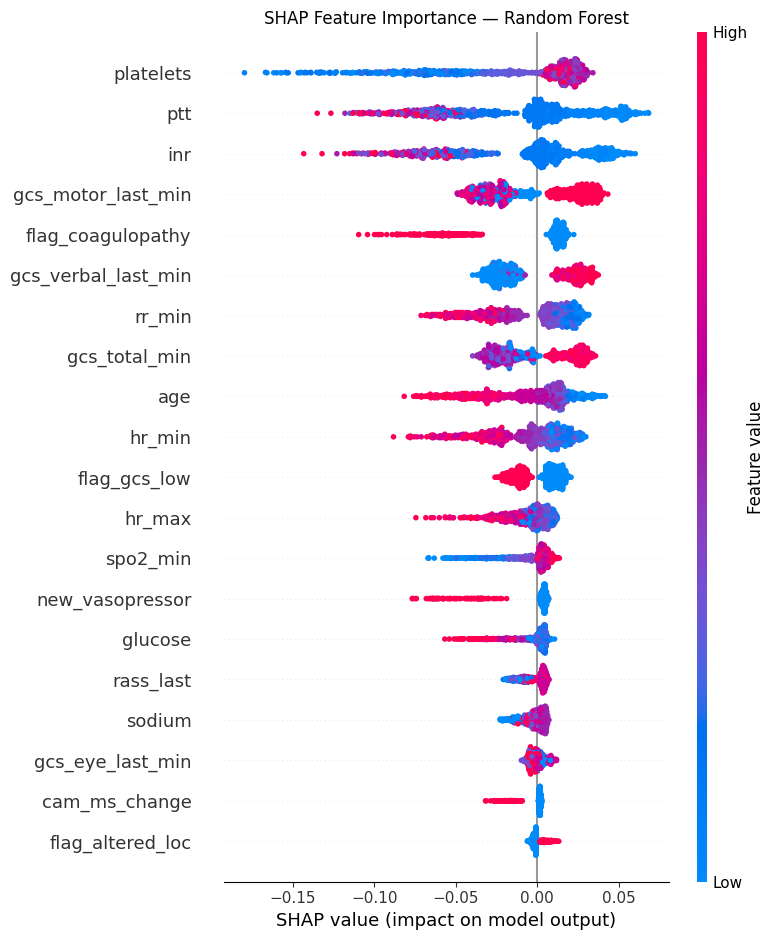

In [3]:
import shap

# Get the Random Forest pipeline
rf_pipeline = results['Random Forest']['pipeline']
rf_model = rf_pipeline.named_steps['classifier']

# Transform test data through the preprocessor only
X_test_transformed = rf_pipeline.named_steps['preprocessor'].transform(X_test)

# Get feature names after one-hot encoding
numeric_feature_names = numeric_features
cat_feature_names = rf_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .named_steps['onehot']\
    .get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_feature_names + cat_feature_names

# SHAP values
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values[1],
    X_test_transformed,
    feature_names=all_feature_names,
    show=False
)
plt.title('SHAP Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300)
plt.show()

In [4]:
# Check INR distribution by CT classification
print(df.groupby('ct_classification')['inr'].describe())
print(df.groupby('ct_classification')['ptt'].describe())
print(df.groupby('ct_classification')['platelets'].describe())

                    count      mean       std  min  25%  50%  75%   max
ct_classification                                                      
Negative           2531.0  1.834370  1.473367  0.8  1.2  1.4  1.9  21.1
Positive            694.0  1.276081  0.614593  0.8  1.0  1.1  1.3  10.2
                    count       mean        std  min   25%   50%   75%    max
ct_classification                                                            
Negative           2531.0  19.871948  15.003885  9.2  12.9  15.1  20.4  150.0
Positive            694.0  14.327954   9.283687  8.9  11.6  12.5  14.1  150.0
                    count        mean         std   min    25%    50%    75%  \
ct_classification                                                              
Negative           3041.0  206.989148  132.226964   5.0  111.0  187.0  272.0   
Positive            831.0  247.110710  105.869719  11.0  183.0  238.0  299.5   

                      max  
ct_classification          
Negative           1376

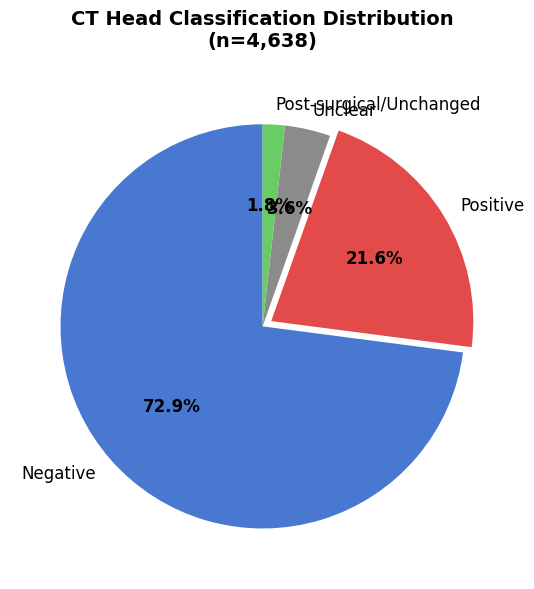

Saved: ct_distribution.png


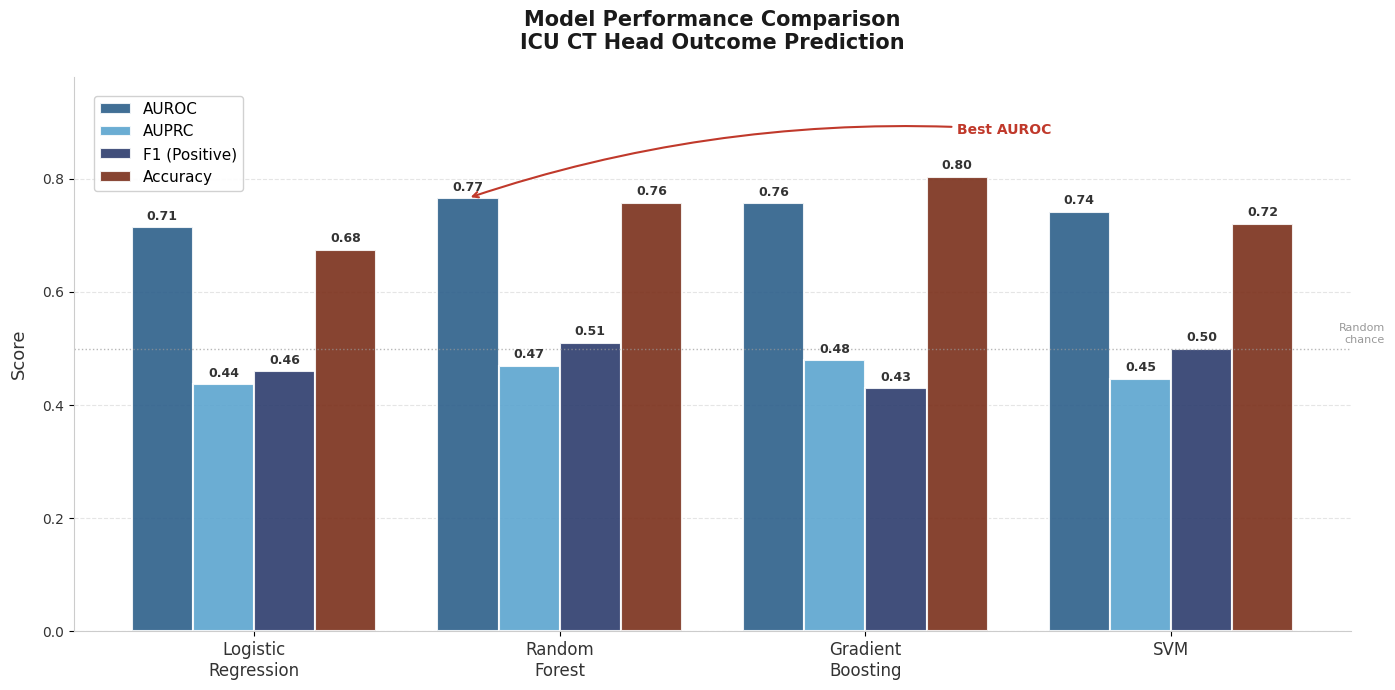

Saved: model_comparison_final.png


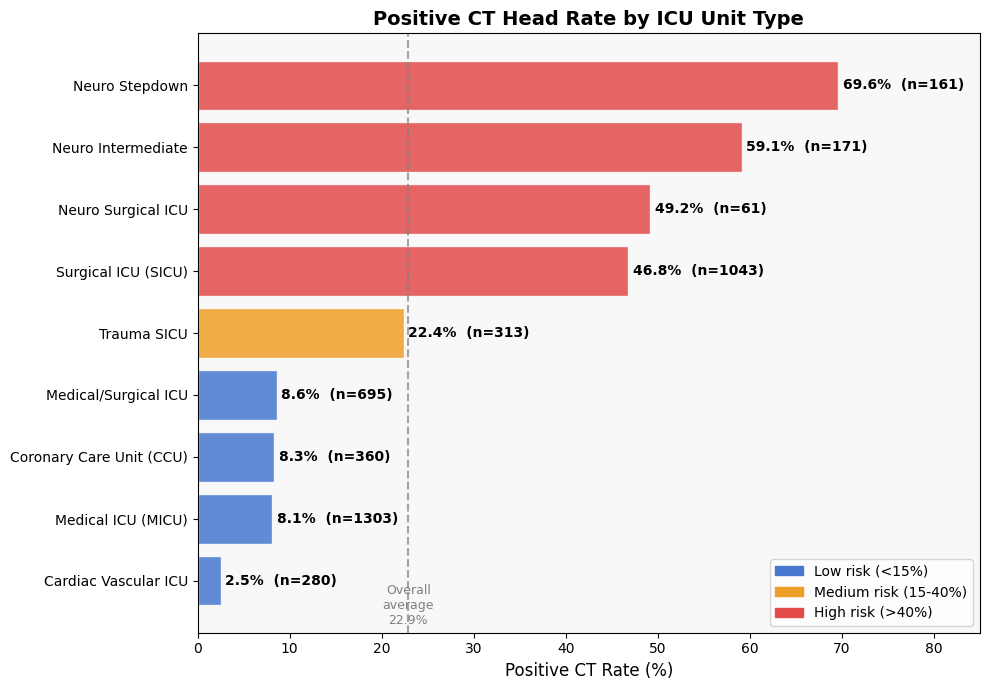

Saved: icu_unit_rates.png

All 3 charts saved! Drop them into your slides.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 1. Pie Chart — CT Classification Distribution ─────────────────────────────
labels = ['Negative', 'Positive', 'Unclear', 'Post-surgical/Unchanged']
sizes = [3383, 1004, 169, 82]
colors = ['#4878CF', '#E24B4A', '#8B8B8B', '#6ACC65']
explode = (0, 0.05, 0, 0)

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax.set_title('CT Head Classification Distribution\n(n=4,638)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('ct_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ct_distribution.png")

# ── 2. Bar Chart — Model Comparison ──────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

models   = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting', 'SVM']
auroc    = [0.714, 0.766, 0.757, 0.742]
auprc    = [0.437, 0.470, 0.479, 0.447]
f1       = [0.46,  0.51,  0.43,  0.50]
accuracy = [0.675, 0.758, 0.804, 0.721]

x     = np.arange(len(models))
width = 0.20

# Professional color palette
color_auroc    = '#2C5F8A'   # deep blue
color_auprc    = '#5BA4CF'   # medium blue
color_f1       = "#2C3C6D"   # forest green
color_accuracy = "#7A2F1A"   # warm amber

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars1 = ax.bar(x - 1.5*width, auroc,    width, label='AUROC',
               color=color_auroc,    alpha=0.90, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x - 0.5*width, auprc,    width, label='AUPRC',
               color=color_auprc,    alpha=0.90, edgecolor='white', linewidth=1.5)
bars3 = ax.bar(x + 0.5*width, f1,       width, label='F1 (Positive)',
               color=color_f1,       alpha=0.90, edgecolor='white', linewidth=1.5)
bars4 = ax.bar(x + 1.5*width, accuracy, width, label='Accuracy',
               color=color_accuracy, alpha=0.90, edgecolor='white', linewidth=1.5)

# Clean value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.008,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color='#333333')

# Styling
ax.set_ylim(0, 0.98)
ax.set_ylabel('Score', fontsize=13, color='#333333', labelpad=10)
ax.set_title('Model Performance Comparison\nICU CT Head Outcome Prediction',
             fontsize=15, fontweight='bold', color='#1a1a1a', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12, color='#333333')
ax.tick_params(axis='y', labelcolor='#333333', labelsize=10)

# Grid lines only horizontal
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Reference line
ax.axhline(y=0.5, color='#999999', linestyle=':', alpha=0.7, linewidth=1)
ax.text(3.7, 0.51, 'Random\nchance', ha='right', fontsize=8, color='#999999')

# Best model annotation
ax.annotate('Best AUROC',
            xy=(1 - 1.5*width, 0.766),
            xytext=(2.3, 0.88),
            arrowprops=dict(arrowstyle='->', color='#C0392B',
                           lw=1.5, connectionstyle='arc3,rad=0.1'),
            fontsize=10, color='#C0392B', fontweight='bold')

# Legend
ax.legend(fontsize=11, framealpha=0.9, edgecolor='#cccccc',
          loc='upper left', bbox_to_anchor=(0.01, 0.98))

plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved: model_comparison_final.png")

# ── 3. Horizontal Bar Chart — Positive CT Rate by ICU Unit ───────────────────
units = [
    'Cardiac Vascular ICU',
    'Medical ICU (MICU)',
    'Coronary Care Unit (CCU)',
    'Medical/Surgical ICU',
    'Trauma SICU',
    'Surgical ICU (SICU)',
    'Neuro Surgical ICU',
    'Neuro Intermediate',
    'Neuro Stepdown'
]
positive_pct = [2.5, 8.1, 8.3, 8.6, 22.4, 46.8, 49.2, 59.1, 69.6]
total_cts    = [280, 1303, 360, 695, 313, 1043, 61, 171, 161]

# Color code by rate
colors_icu = []
for pct in positive_pct:
    if pct < 15:
        colors_icu.append('#4878CF')   # blue = low risk
    elif pct < 40:
        colors_icu.append('#EF9F27')   # amber = medium risk
    else:
        colors_icu.append('#E24B4A')   # red = high risk

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(units, positive_pct, color=colors_icu, alpha=0.85, edgecolor='white')

# Add value labels
for bar, total in zip(bars, total_cts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{bar.get_width()}%  (n={total})',
            ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, 85)
ax.set_xlabel('Positive CT Rate (%)', fontsize=12)
ax.set_title('Positive CT Head Rate by ICU Unit Type', fontsize=14, fontweight='bold')
ax.set_facecolor('#f8f8f8')
ax.axvline(x=22.9, color='gray', linestyle='--', alpha=0.7)
ax.text(22.9, -0.7, 'Overall\naverage\n22.9%', ha='center', fontsize=9, color='gray')

# Legend
low    = mpatches.Patch(color='#4878CF', label='Low risk (<15%)')
medium = mpatches.Patch(color='#EF9F27', label='Medium risk (15-40%)')
high   = mpatches.Patch(color='#E24B4A', label='High risk (>40%)')
ax.legend(handles=[low, medium, high], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('icu_unit_rates.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: icu_unit_rates.png")

print("\nAll 3 charts saved! Drop them into your slides.")

In [6]:
from sklearn.metrics import brier_score_loss

for name, res in results.items():
    brier = brier_score_loss(y_test, res['y_prob'])
    print(f"{name}: Brier Score = {brier:.3f}")

Logistic Regression: Brier Score = 0.209
Random Forest: Brier Score = 0.179
Gradient Boosting: Brier Score = 0.144
SVM: Brier Score = 0.146


In [7]:
from sklearn.metrics import brier_score_loss

summary = pd.DataFrame({
    name: {
        'AUROC':       f"{res['AUROC']:.3f}",
        'AUPRC':       f"{res['AUPRC']:.3f}",
        'Accuracy':    f"{res['Accuracy']:.3f}",
        'Brier Score': f"{brier_score_loss(y_test, res['y_prob']):.3f}"
    }
    for name, res in results.items()
}).T
print(summary)

                     AUROC  AUPRC Accuracy Brier Score
Logistic Regression  0.714  0.437    0.675       0.209
Random Forest        0.766  0.470    0.758       0.179
Gradient Boosting    0.757  0.479    0.804       0.144
SVM                  0.742  0.447    0.721       0.146


In [8]:
# Demographic summary by CT outcome
summary = df.groupby('ct_classification').agg(
    n = ('age', 'count'),
    age_median = ('age', 'median'),
    age_iqr_low = ('age', lambda x: x.quantile(0.25)),
    age_iqr_high = ('age', lambda x: x.quantile(0.75)),
    gcs_median = ('gcs_total_min', 'median'),
    inr_median = ('inr', 'median'),
    ptt_median = ('ptt', 'median'),
    platelets_median = ('platelets', 'median'),
    pct_male = ('gender', lambda x: (x == 'M').mean() * 100)
).round(1)

print(summary)

                      n  age_median  age_iqr_low  age_iqr_high  gcs_median  \
ct_classification                                                            
Negative           3383        63.0         51.0          73.0         9.0   
Positive           1004        57.0         46.0          67.0        14.0   

                   inr_median  ptt_median  platelets_median  pct_male  
ct_classification                                                      
Negative                  1.4        15.1             187.0      54.1  
Positive                  1.1        12.5             238.0      50.5  


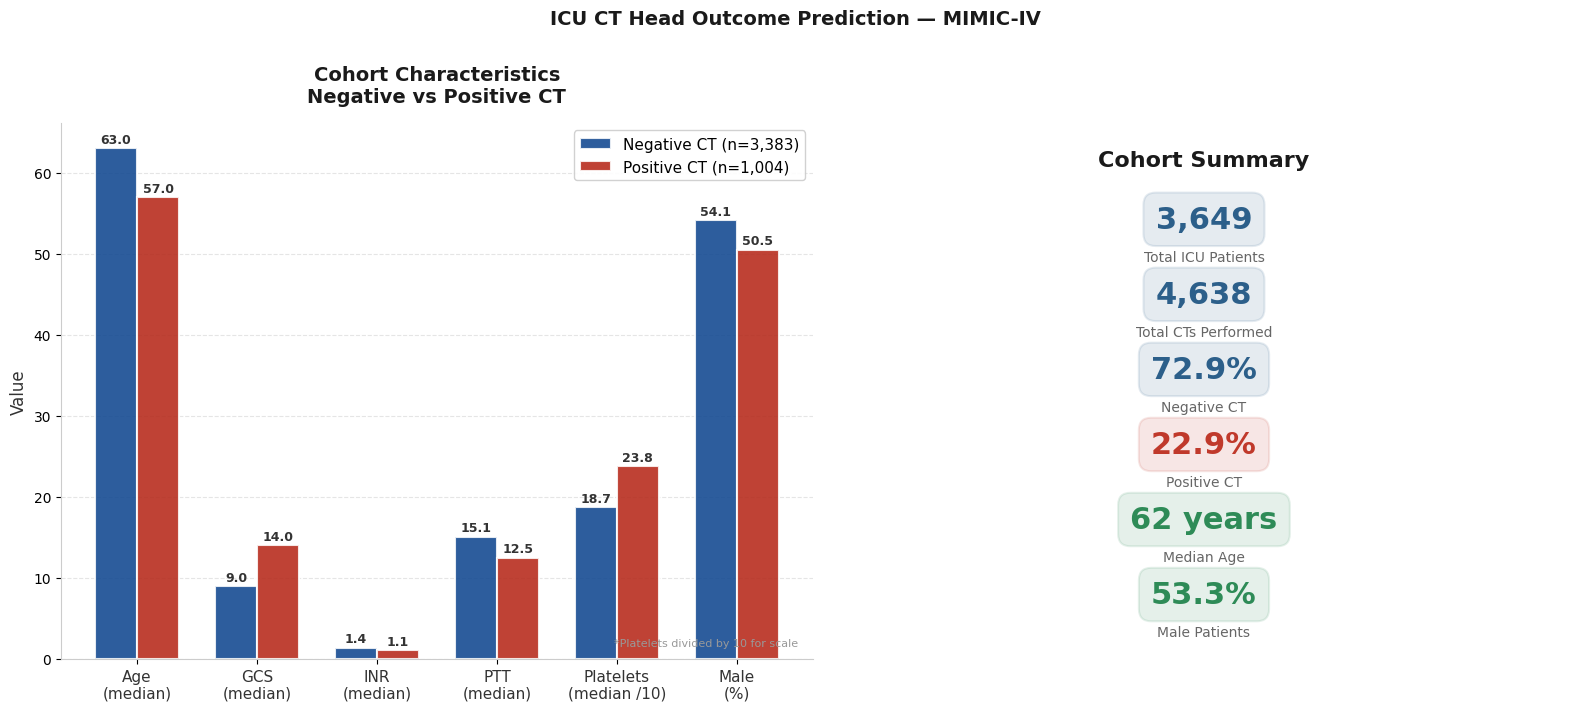

Saved: cohort_description.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ─────────────────────────────────────────────────────────────────────
categories = ['Age\n(median)', 'GCS\n(median)', 'INR\n(median)', 
              'PTT\n(median)', 'Platelets\n(median /10)', 'Male\n(%)']

negative = [63.0, 9.0, 1.4, 15.1, 187.0/10, 54.1]
positive = [57.0, 14.0, 1.1, 12.5, 238.0/10, 50.5]

x = np.arange(len(categories))
width = 0.35

# ── Colors ────────────────────────────────────────────────────────────────────
color_neg = "#104790"   # deep blue for negative
color_pos = "#B62819"   # deep red for positive

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# ── Left plot: Demographic comparison bar chart ───────────────────────────────
ax = axes[0]
ax.set_facecolor('white')

bars1 = ax.bar(x - width/2, negative, width,
               label='Negative CT (n=3,383)',
               color=color_neg, alpha=0.88,
               edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, positive, width,
               label='Positive CT (n=1,004)',
               color=color_pos, alpha=0.88,
               edgecolor='white', linewidth=1.5)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333333')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11, color='#333333')
ax.set_ylabel('Value', fontsize=12, color='#333333')
ax.set_title('Cohort Characteristics\nNegative vs Positive CT', 
             fontsize=14, fontweight='bold', color='#1a1a1a', pad=15)
ax.legend(fontsize=11, framealpha=0.9, edgecolor='#cccccc')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Note about platelets
ax.text(0.98, 0.02, '*Platelets divided by 10 for scale',
        transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right', va='bottom')

# ── Right plot: Summary infographic ──────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('white')
ax2.axis('off')

# Title
ax2.text(0.5, 0.95, 'Cohort Summary',
         ha='center', va='top', fontsize=16,
         fontweight='bold', color='#1a1a1a',
         transform=ax2.transAxes)

# Key stats boxes
stats = [
    ('Total ICU Patients',   '3,649',   '#2C5F8A'),
    ('Total CTs Performed',  '4,638',   '#2C5F8A'),  # ← changed
    ('Negative CT',          '72.9%',   '#2C5F8A'),
    ('Positive CT',          '22.9%',   '#C0392B'),
    ('Median Age',           '62 years','#2E8B57'),
    ('Male Patients',        '53.3%',   '#2E8B57'),
]

y_positions = [0.82, 0.68, 0.54, 0.40, 0.26, 0.12]

for (label, value, color), y in zip(stats, y_positions):
    # Background box
    bbox = dict(boxstyle='round,pad=0.4', facecolor=color,
                alpha=0.12, edgecolor=color, linewidth=1.5)
    ax2.text(0.5, y, f'{value}', ha='center', va='center',
             fontsize=22, fontweight='bold', color=color,
             transform=ax2.transAxes, bbox=bbox)
    ax2.text(0.5, y - 0.07, label, ha='center', va='center',
             fontsize=10, color='#666666',
             transform=ax2.transAxes)

plt.suptitle('ICU CT Head Outcome Prediction — MIMIC-IV',
             fontsize=14, fontweight='bold', color='#1a1a1a', y=1.01)

plt.tight_layout()
plt.savefig('cohort_description.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: cohort_description.png")

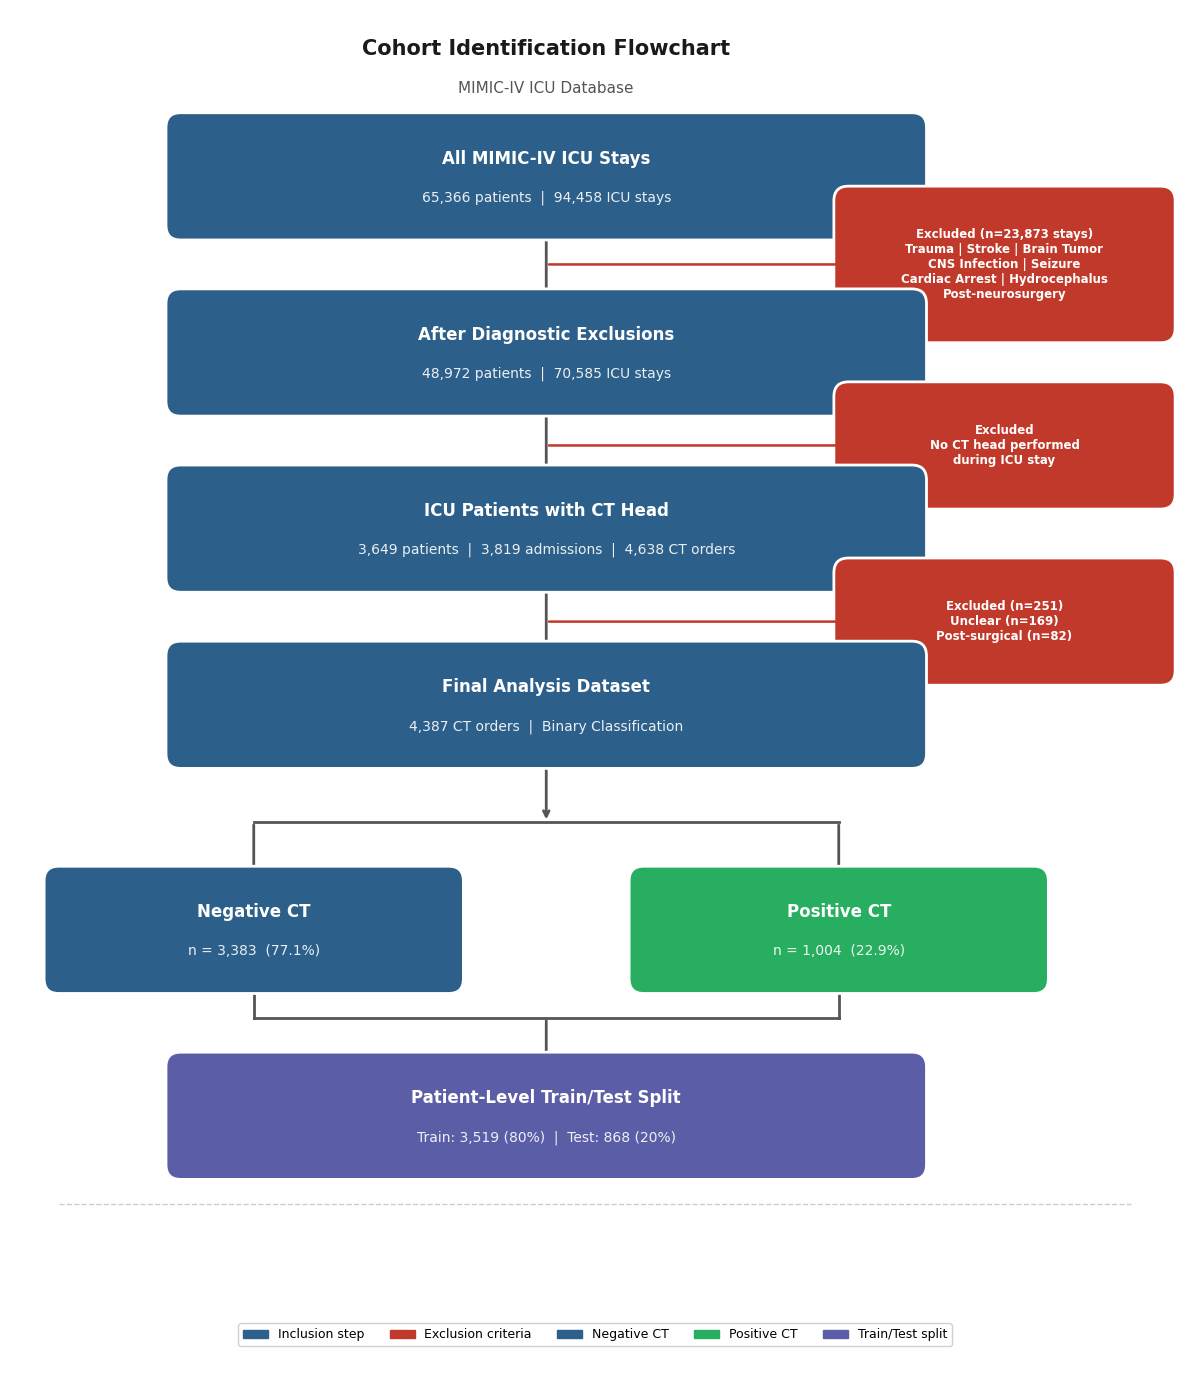

Saved: cohort_flowchart_final.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 14))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')
ax.set_xlim(0, 12)
ax.set_ylim(0, 14)

# ── Color scheme ──────────────────────────────────────────────────────────────
color_include = '#2C5F8A'
color_exclude = '#C0392B'
color_neg     = '#2C5F8A'
color_pos     = '#27AE60'
color_split   = '#5B5EA6'

# ── Helper functions ──────────────────────────────────────────────────────────
def draw_box(ax, x, y, width, height, title, subtitle, color,
             title_size=12, sub_size=10):
    box = FancyBboxPatch(
        (x - width/2, y - height/2),
        width, height,
        boxstyle='round,pad=0.15',
        facecolor=color,
        edgecolor='white',
        linewidth=2,
        zorder=3
    )
    ax.add_patch(box)
    if subtitle:
        ax.text(x, y + 0.18, title,
                ha='center', va='center',
                fontsize=title_size,
                fontweight='bold',
                color='white', zorder=4)
        ax.text(x, y - 0.22, subtitle,
                ha='center', va='center',
                fontsize=sub_size,
                color='white', alpha=0.9,
                zorder=4)
    else:
        ax.text(x, y, title,
                ha='center', va='center',
                fontsize=title_size,
                fontweight='bold',
                color='white', zorder=4)

def draw_arrow(ax, x, y1, y2, color='#555555'):
    ax.annotate('',
                xy=(x, y2),
                xytext=(x, y1),
                arrowprops=dict(
                    arrowstyle='->',
                    color=color,
                    lw=2.0
                ), zorder=2)

def draw_exclusion(ax, x_center, y, width, height, lines):
    box = FancyBboxPatch(
        (x_center - width/2, y - height/2),
        width, height,
        boxstyle='round,pad=0.15',
        facecolor=color_exclude,
        edgecolor='white',
        linewidth=2,
        zorder=3
    )
    ax.add_patch(box)
    text = '\n'.join(lines)
    ax.text(x_center, y, text,
            ha='center', va='center',
            fontsize=8.5,
            fontweight='bold',
            color='white',
            zorder=4,
            multialignment='center')

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(5.5, 13.6, 'Cohort Identification Flowchart',
        ha='center', va='center',
        fontsize=15, fontweight='bold', color='#1a1a1a')
ax.text(5.5, 13.2, 'MIMIC-IV ICU Database',
        ha='center', va='center',
        fontsize=11, color='#555555')

# ── Box 1: All ICU stays ──────────────────────────────────────────────────────
draw_box(ax, 5.5, 12.3, 7.5, 1.0,
         'All MIMIC-IV ICU Stays',
         '65,366 patients  |  94,458 ICU stays',
         color_include)

# Arrow 1
draw_arrow(ax, 5.5, 11.8, 10.95)

# Exclusion 1
draw_exclusion(ax, 10.2, 11.4, 3.2, 1.3,
               ['Excluded (n=23,873 stays)',
                'Trauma | Stroke | Brain Tumor',
                'CNS Infection | Seizure',
                'Cardiac Arrest | Hydrocephalus',
                'Post-neurosurgery'])
ax.annotate('',
            xy=(8.6, 11.4),
            xytext=(5.5, 11.4),
            arrowprops=dict(arrowstyle='->', color=color_exclude, lw=1.8))

# ── Box 2: After exclusions ───────────────────────────────────────────────────
draw_box(ax, 5.5, 10.5, 7.5, 1.0,
         'After Diagnostic Exclusions',
         '48,972 patients  |  70,585 ICU stays',
         color_include)

# Arrow 2
draw_arrow(ax, 5.5, 10.0, 9.15)

# Exclusion 2
draw_exclusion(ax, 10.2, 9.55, 3.2, 1.0,
               ['Excluded',
                'No CT head performed',
                'during ICU stay'])
ax.annotate('',
            xy=(8.6, 9.55),
            xytext=(5.5, 9.55),
            arrowprops=dict(arrowstyle='->', color=color_exclude, lw=1.8))

# ── Box 3: ICU patients with CT ───────────────────────────────────────────────
draw_box(ax, 5.5, 8.7, 7.5, 1.0,
         'ICU Patients with CT Head',
         '3,649 patients  |  3,819 admissions  |  4,638 CT orders',
         color_include)

# Arrow 3
draw_arrow(ax, 5.5, 8.2, 7.35)

# Exclusion 3
draw_exclusion(ax, 10.2, 7.75, 3.2, 1.0,
               ['Excluded (n=251)',
                'Unclear (n=169)',
                'Post-surgical (n=82)'])
ax.annotate('',
            xy=(8.6, 7.75),
            xytext=(5.5, 7.75),
            arrowprops=dict(arrowstyle='->', color=color_exclude, lw=1.8))

# ── Box 4: Final dataset ──────────────────────────────────────────────────────
draw_box(ax, 5.5, 6.9, 7.5, 1.0,
         'Final Analysis Dataset',
         '4,387 CT orders  |  Binary Classification',
         color_include)

# Arrow splits into two
draw_arrow(ax, 5.5, 6.4, 5.7)
ax.plot([2.5, 8.5], [5.7, 5.7], color='#555555', lw=2, zorder=2)
ax.annotate('', xy=(2.5, 5.1), xytext=(2.5, 5.7),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=2))
ax.annotate('', xy=(8.5, 5.1), xytext=(8.5, 5.7),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=2))

# ── Box 5a: Negative CT ───────────────────────────────────────────────────────
draw_box(ax, 2.5, 4.6, 4.0, 1.0,
         'Negative CT',
         'n = 3,383  (77.1%)',
         color_neg)

# ── Box 5b: Positive CT ───────────────────────────────────────────────────────
draw_box(ax, 8.5, 4.6, 4.0, 1.0,
         'Positive CT',
         'n = 1,004  (22.9%)',
         color_pos)

# Arrows from both boxes down to train/test
ax.plot([2.5, 2.5], [4.1, 3.7], color='#555555', lw=2)
ax.plot([8.5, 8.5], [4.1, 3.7], color='#555555', lw=2)
ax.plot([2.5, 8.5], [3.7, 3.7], color='#555555', lw=2)
draw_arrow(ax, 5.5, 3.7, 3.1)

# ── Box 6: Train/Test split ───────────────────────────────────────────────────
draw_box(ax, 5.5, 2.7, 7.5, 1.0,
         'Patient-Level Train/Test Split',
         'Train: 3,519 (80%)  |  Test: 868 (20%)',
         color_split)

# ── Divider line ──────────────────────────────────────────────────────────────
ax.plot([0.5, 11.5], [1.8, 1.8],
        color='#cccccc', lw=1, linestyle='--')

# ── Legend ────────────────────────────────────────────────────────────────────
inc = mpatches.Patch(color=color_include, label='Inclusion step')
exc = mpatches.Patch(color=color_exclude, label='Exclusion criteria')
neg = mpatches.Patch(color=color_neg,     label='Negative CT')
pos = mpatches.Patch(color=color_pos,     label='Positive CT')
spl = mpatches.Patch(color=color_split,   label='Train/Test split')

ax.legend(handles=[inc, exc, neg, pos, spl],
          loc='lower center',
          ncol=5,
          fontsize=9,
          framealpha=0.9,
          edgecolor='#cccccc',
          bbox_to_anchor=(0.5, 0.02))

plt.tight_layout()
plt.savefig('cohort_flowchart_final.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: cohort_flowchart_final.png")

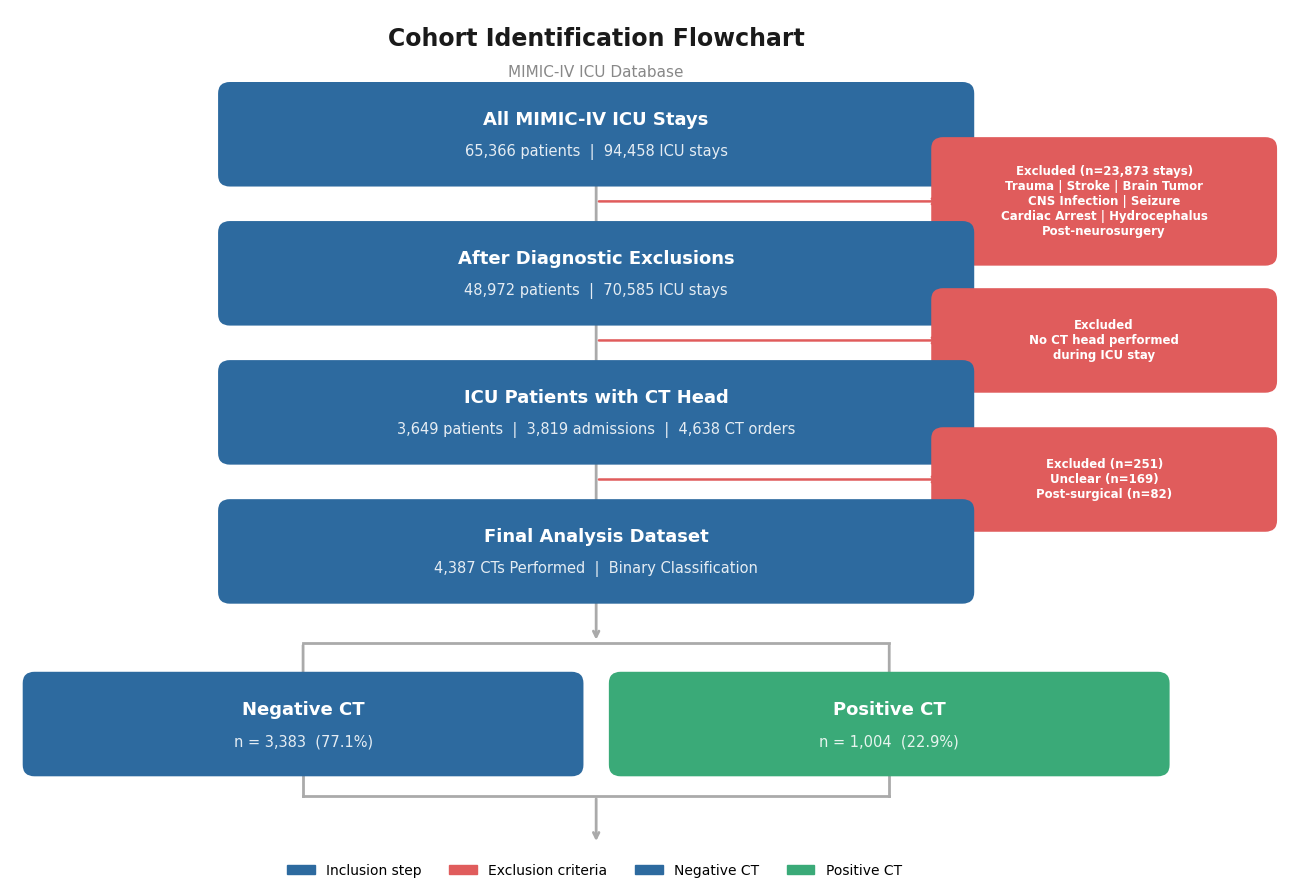

Saved: cohort_flowchart_powerpoint.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── Figure size optimized for 4:3 PowerPoint ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')
ax.set_xlim(0, 13)
ax.set_ylim(0, 9)

# ── Modern minimalistic palette ───────────────────────────────────────────────
color_include = '#2D6A9F'   # clean blue
color_exclude = '#E05C5C'   # soft red
color_neg     = '#2D6A9F'   # clean blue
color_pos     = '#3AAA78'   # mint green
color_split   = '#7B68B5'   # soft purple
color_text    = 'white'

# ── Helper functions ──────────────────────────────────────────────────────────
def draw_box(ax, x, y, width, height, title, subtitle, color,
             title_size=13, sub_size=10.5):
    box = FancyBboxPatch(
        (x - width/2, y - height/2),
        width, height,
        boxstyle='round,pad=0.12',
        facecolor=color,
        edgecolor='none',
        linewidth=0,
        zorder=3
    )
    ax.add_patch(box)
    if subtitle:
        ax.text(x, y + 0.15, title,
                ha='center', va='center',
                fontsize=title_size,
                fontweight='bold',
                color=color_text, zorder=4)
        ax.text(x, y - 0.18, subtitle,
                ha='center', va='center',
                fontsize=sub_size,
                color=color_text,
                alpha=0.88,
                zorder=4)
    else:
        ax.text(x, y, title,
                ha='center', va='center',
                fontsize=title_size,
                fontweight='bold',
                color=color_text, zorder=4)

def draw_arrow(ax, x, y1, y2):
    ax.annotate('',
                xy=(x, y2),
                xytext=(x, y1),
                arrowprops=dict(
                    arrowstyle='->',
                    color='#AAAAAA',
                    lw=2.0
                ), zorder=2)

def draw_exclusion(ax, x_center, y, width, height, lines):
    box = FancyBboxPatch(
        (x_center - width/2, y - height/2),
        width, height,
        boxstyle='round,pad=0.12',
        facecolor=color_exclude,
        edgecolor='none',
        linewidth=0,
        zorder=3
    )
    ax.add_patch(box)
    text = '\n'.join(lines)
    ax.text(x_center, y, text,
            ha='center', va='center',
            fontsize=8.5,
            fontweight='bold',
            color=color_text,
            zorder=4,
            multialignment='center')

def draw_exclude_arrow(ax, x_from, x_to, y):
    ax.annotate('',
                xy=(x_to, y),
                xytext=(x_from, y),
                arrowprops=dict(
                    arrowstyle='->',
                    color=color_exclude,
                    lw=1.8
                ), zorder=2)

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(6.0, 8.7, 'Cohort Identification Flowchart',
        ha='center', va='center',
        fontsize=17, fontweight='bold', color='#1a1a1a')
ax.text(6.0, 8.35, 'MIMIC-IV ICU Database',
        ha='center', va='center',
        fontsize=11, color='#888888')

# ── Box 1: All ICU stays ──────────────────────────────────────────────────────
draw_box(ax, 6.0, 7.7, 7.5, 0.85,
         'All MIMIC-IV ICU Stays',
         '65,366 patients  |  94,458 ICU stays',
         color_include)

draw_arrow(ax, 6.0, 7.27, 6.65)

# Exclusion 1
draw_exclusion(ax, 11.2, 7.0, 3.3, 1.1,
               ['Excluded (n=23,873 stays)',
                'Trauma | Stroke | Brain Tumor',
                'CNS Infection | Seizure',
                'Cardiac Arrest | Hydrocephalus',
                'Post-neurosurgery'])
draw_exclude_arrow(ax, 6.0, 9.55, 7.0)

# ── Box 2: After exclusions ───────────────────────────────────────────────────
draw_box(ax, 6.0, 6.25, 7.5, 0.85,
         'After Diagnostic Exclusions',
         '48,972 patients  |  70,585 ICU stays',
         color_include)

draw_arrow(ax, 6.0, 5.82, 5.20)

# Exclusion 2
draw_exclusion(ax, 11.2, 5.55, 3.3, 0.85,
               ['Excluded',
                'No CT head performed',
                'during ICU stay'])
draw_exclude_arrow(ax, 6.0, 9.55, 5.55)

# ── Box 3: ICU patients with CT ───────────────────────────────────────────────
draw_box(ax, 6.0, 4.80, 7.5, 0.85,
         'ICU Patients with CT Head',
         '3,649 patients  |  3,819 admissions  |  4,638 CT orders',
         color_include)

draw_arrow(ax, 6.0, 4.37, 3.75)

# Exclusion 3
draw_exclusion(ax, 11.2, 4.1, 3.3, 0.85,
               ['Excluded (n=251)',
                'Unclear (n=169)',
                'Post-surgical (n=82)'])
draw_exclude_arrow(ax, 6.0, 9.55, 4.1)

# ── Box 4: Final dataset ──────────────────────────────────────────────────────
draw_box(ax, 6.0, 3.35, 7.5, 0.85,
         'Final Analysis Dataset',
         '4,387 CTs Performed  |  Binary Classification',
         color_include)

# Split arrow
draw_arrow(ax, 6.0, 2.92, 2.4)
ax.plot([3.0, 9.0], [2.4, 2.4],
        color='#AAAAAA', lw=2, zorder=2)
ax.annotate('', xy=(3.0, 1.9), xytext=(3.0, 2.4),
            arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=2))
ax.annotate('', xy=(9.0, 1.9), xytext=(9.0, 2.4),
            arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=2))

# ── Box 5a: Negative CT ───────────────────────────────────────────────────────
draw_box(ax, 3.0, 1.55, 5.5, 0.85,
         'Negative CT',
         'n = 3,383  (77.1%)',
         color_neg)

# ── Box 5b: Positive CT ───────────────────────────────────────────────────────
draw_box(ax, 9.0, 1.55, 5.5, 0.85,
         'Positive CT',
         'n = 1,004  (22.9%)',
         color_pos)

# Arrows from both boxes to train/test
ax.plot([3.0, 3.0], [1.12, 0.8], color='#AAAAAA', lw=2)
ax.plot([9.0, 9.0], [1.12, 0.8], color='#AAAAAA', lw=2)
ax.plot([3.0, 9.0], [0.8, 0.8],  color='#AAAAAA', lw=2)
draw_arrow(ax, 6.0, 0.8, 0.3)

# ── Legend ────────────────────────────────────────────────────────────────────
inc = mpatches.Patch(color=color_include, label='Inclusion step')
exc = mpatches.Patch(color=color_exclude, label='Exclusion criteria')
neg = mpatches.Patch(color=color_neg,     label='Negative CT')
pos = mpatches.Patch(color=color_pos,     label='Positive CT')

ax.legend(handles=[inc, exc, neg, pos],
          loc='lower center',
          ncol=4,
          fontsize=10,
          frameon=False,
          bbox_to_anchor=(0.46, -0.02))

plt.tight_layout()
plt.savefig('cohort_flowchart_powerpoint.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: cohort_flowchart_powerpoint.png")

In [12]:
import pandas as pd

df = pd.read_csv('final_ct_head_dataset.csv')

print("── Shape ──")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

print("\n── CT Classification ──")
print(df['ct_classification'].value_counts())

print("\n── Unique counts ──")
print(f"Unique patients: {df['subject_id'].nunique()}")
print(f"Unique admissions: {df['hadm_id'].nunique()}")
print(f"Unique stays: {df['stay_id'].nunique()}")

── Shape ──
Total rows: 4638
Total columns: 57

── CT Classification ──
ct_classification
Negative                   3383
Positive                   1004
Unclear                     169
Post-surgical/Unchanged      82
Name: count, dtype: int64

── Unique counts ──
Unique patients: 3649
Unique admissions: 3819
Unique stays: 3905


In [13]:
# Run this to verify
print(df.groupby('ct_classification')[['gcs_total_min']].median())

                         gcs_total_min
ct_classification                     
Negative                           9.0
Positive                          14.0
Post-surgical/Unchanged           14.0
Unclear                            9.0
